Initializing access control system...

ACCESS CONTROL SYSTEM FOR RENTAL POINT

ACCESS DECISIONS:
        user    role      resource operation  granted
  admin_user   admin  contract_001      read     True
  admin_user   admin  contract_001    delete     True
manager_user manager  contract_001      read    False
manager_user manager  contract_001     write    False
manager_user manager  contract_001    delete    False
 client_user  client  contract_001      read    False
 client_user  client    price_list      read     True
 client_user  client    price_list     write    False
manager_user manager inventory_001      read     True
manager_user manager inventory_001     write    False
 client_user  client inventory_001      read    False
 client_user  client inventory_001     write    False

STATISTICS:
  Total access attempts: 12.0
  Granted: 4.0
  Denied: 8.0
  Grant rate (%): 33.33

SECURITY MODEL VERIFICATION:
  [X] RBAC - Role-based access control implemented
  [X] MAC - Mandatory ac

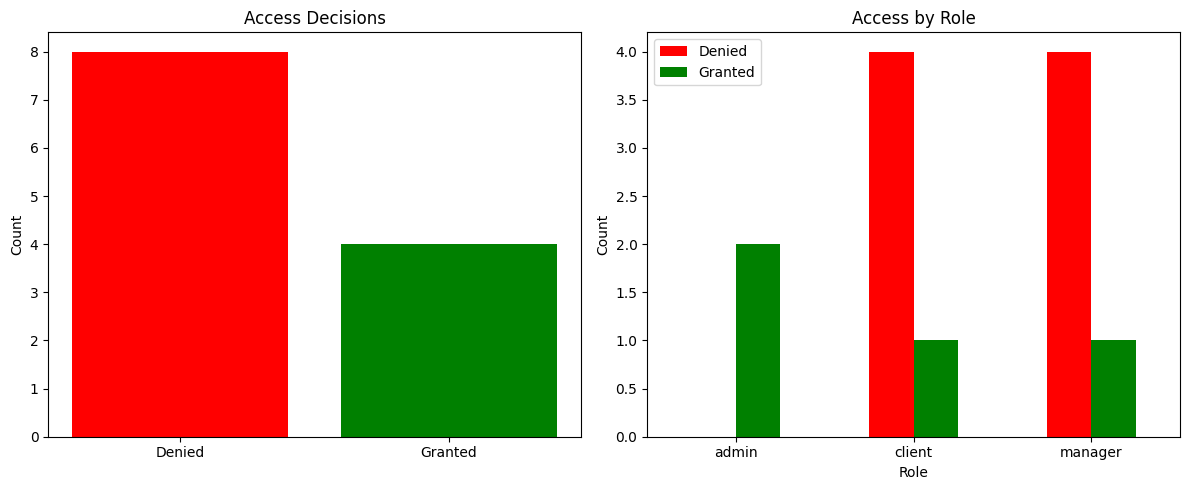


Files saved successfully:
  - access_results.csv
  - access_statistics.csv
  - access_log.csv

Execution completed successfully


In [3]:
# -*- coding: utf-8 -*-
"""
Access Control System for Rental Point Information System
Implementation of RBAC + Mandatory Access Control + ACL
"""

import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, Set, List, Tuple
from enum import Enum
import sys
import os


class SecurityLevel(Enum):
    PUBLIC = 1
    INTERNAL = 2
    CONFIDENTIAL = 3


class Operation(Enum):
    READ = "read"
    WRITE = "write"
    DELETE = "delete"
    CREATE = "create"


@dataclass
class Role:
    name: str
    permissions: Set[Operation] = field(default_factory=set)


@dataclass
class User:
    username: str
    role: Role
    clearance: SecurityLevel


@dataclass
class Resource:
    id: str
    owner: str
    acl: Dict[str, Set[Operation]]
    mandatory_level: SecurityLevel


class AccessMediator:
    def __init__(self):
        self.access_log: List[Tuple[str, str, str, bool, str]] = []

    def check_access(self, user: User, resource: Resource, operation: Operation) -> bool:
        if operation not in user.role.permissions:
            self.access_log.append((user.username, resource.id, operation.value, False, "RBAC_denied"))
            return False

        if operation == Operation.READ:
            if user.clearance.value < resource.mandatory_level.value:
                self.access_log.append((user.username, resource.id, operation.value, False, "mandatory_read_denied"))
                return False
        elif operation in (Operation.WRITE, Operation.DELETE):
            if user.clearance.value != resource.mandatory_level.value:
                self.access_log.append((user.username, resource.id, operation.value, False, "mandatory_write_denied"))
                return False

        if user.username in resource.acl:
            if operation in resource.acl[user.username]:
                self.access_log.append((user.username, resource.id, operation.value, True, "ACL_granted"))
                return True

        if user.username == resource.owner:
            self.access_log.append((user.username, resource.id, operation.value, True, "owner_granted"))
            return True

        self.access_log.append((user.username, resource.id, operation.value, False, "no_permission"))
        return False


def create_roles() -> Dict[str, Role]:
    admin_role = Role("admin", {Operation.READ, Operation.WRITE, Operation.DELETE, Operation.CREATE})
    manager_role = Role("manager", {Operation.READ, Operation.WRITE, Operation.CREATE})
    client_role = Role("client", {Operation.READ, Operation.CREATE})

    return {
        "admin": admin_role,
        "manager": manager_role,
        "client": client_role
    }


def create_users(roles: Dict[str, Role]) -> Dict[str, User]:
    users = {
        "admin_user": User("admin_user", roles["admin"], SecurityLevel.CONFIDENTIAL),
        "manager_user": User("manager_user", roles["manager"], SecurityLevel.INTERNAL),
        "client_user": User("client_user", roles["client"], SecurityLevel.PUBLIC)
    }
    return users


def create_resources() -> Dict[str, Resource]:
    resources = {
        "contract_001": Resource(
            id="contract_001",
            owner="admin_user",
            acl={"manager_user": {Operation.READ, Operation.WRITE}},
            mandatory_level=SecurityLevel.CONFIDENTIAL
        ),
        "inventory_001": Resource(
            id="inventory_001",
            owner="admin_user",
            acl={"manager_user": {Operation.READ}, "client_user": {Operation.READ}},
            mandatory_level=SecurityLevel.INTERNAL
        ),
        "price_list": Resource(
            id="price_list",
            owner="admin_user",
            acl={"client_user": {Operation.READ}},
            mandatory_level=SecurityLevel.PUBLIC
        )
    }
    return resources


def run_access_scenarios(mediator: AccessMediator, users: Dict[str, User], resources: Dict[str, Resource]) -> pd.DataFrame:
    scenarios = [
        (users["admin_user"], resources["contract_001"], Operation.READ),
        (users["admin_user"], resources["contract_001"], Operation.DELETE),
        (users["manager_user"], resources["contract_001"], Operation.READ),
        (users["manager_user"], resources["contract_001"], Operation.WRITE),
        (users["manager_user"], resources["contract_001"], Operation.DELETE),
        (users["client_user"], resources["contract_001"], Operation.READ),
        (users["client_user"], resources["price_list"], Operation.READ),
        (users["client_user"], resources["price_list"], Operation.WRITE),
        (users["manager_user"], resources["inventory_001"], Operation.READ),
        (users["manager_user"], resources["inventory_001"], Operation.WRITE),
        (users["client_user"], resources["inventory_001"], Operation.READ),
        (users["client_user"], resources["inventory_001"], Operation.WRITE),
    ]

    results = []
    for user, resource, operation in scenarios:
        granted = mediator.check_access(user, resource, operation)
        results.append({
            "user": user.username,
            "role": user.role.name,
            "resource": resource.id,
            "operation": operation.value,
            "granted": granted,
            "resource_level": resource.mandatory_level.name,
            "user_clearance": user.clearance.name
        })

    return pd.DataFrame(results)


def create_statistics(df: pd.DataFrame, log: List[Tuple]) -> pd.DataFrame:
    stats = []

    total_attempts = len(df)
    granted = df["granted"].sum()
    denied = total_attempts - granted

    stats.append(("Total access attempts", total_attempts))
    stats.append(("Granted", granted))
    stats.append(("Denied", denied))
    if total_attempts > 0:
        stats.append(("Grant rate (%)", round(granted/total_attempts*100, 2)))
    else:
        stats.append(("Grant rate (%)", 0))

    return pd.DataFrame(stats, columns=["metric", "value"])


def plot_results(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    granted_counts = df["granted"].value_counts()
    axes[0].bar(["Denied", "Granted"], [granted_counts.get(False, 0), granted_counts.get(True, 0)],
                color=["red", "green"])
    axes[0].set_title("Access Decisions")
    axes[0].set_ylabel("Count")

    role_access = df.groupby(["role", "granted"]).size().unstack(fill_value=0)
    role_access.plot(kind="bar", ax=axes[1], color=["red", "green"])
    axes[1].set_title("Access by Role")
    axes[1].set_xlabel("Role")
    axes[1].set_ylabel("Count")
    axes[1].legend(["Denied", "Granted"])
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()

    try:
        plt.savefig("access_control_results.png", dpi=150, bbox_inches="tight")
        print("\nPlot saved as 'access_control_results.png'")
    except:
        print("\nNote: Could not save plot file, but display is available")

    plt.show()


def save_results_to_csv(df: pd.DataFrame, stats: pd.DataFrame, log: List[Tuple]):
    try:
        df.to_csv("access_results.csv", index=False)
        stats.to_csv("access_statistics.csv", index=False)

        log_df = pd.DataFrame(log, columns=["user", "resource", "operation", "granted", "reason"])
        log_df.to_csv("access_log.csv", index=False)

        print("\nFiles saved successfully:")
        print("  - access_results.csv")
        print("  - access_statistics.csv")
        print("  - access_log.csv")
    except Exception as e:
        print(f"\nNote: Could not save CSV files: {e}")


def print_summary(df: pd.DataFrame, stats: pd.DataFrame):
    print("\n" + "="*70)
    print("ACCESS CONTROL SYSTEM FOR RENTAL POINT")
    print("="*70)

    print("\nACCESS DECISIONS:")
    print(df[["user", "role", "resource", "operation", "granted"]].to_string(index=False))

    print("\nSTATISTICS:")
    for _, row in stats.iterrows():
        print(f"  {row['metric']}: {row['value']}")

    print("\nSECURITY MODEL VERIFICATION:")
    print("  [X] RBAC - Role-based access control implemented")
    print("  [X] MAC - Mandatory access control with 3 levels")
    print("  [X] ACL - Per-resource access control lists")
    print("  [X] Owner-based access")
    print("\nSystem initialization complete.")
    print("All access control mechanisms are operational.")


def main():
    print("Initializing access control system...")

    roles = create_roles()
    users = create_users(roles)
    resources = create_resources()
    mediator = AccessMediator()

    df = run_access_scenarios(mediator, users, resources)
    stats = create_statistics(df, mediator.access_log)

    print_summary(df, stats)
    plot_results(df)
    save_results_to_csv(df, stats, mediator.access_log)

    print("\n" + "="*70)
    print("Execution completed successfully")
    print("="*70)


if __name__ == "__main__":
    main()